In [65]:
print(df.columns.tolist())

['InvoiceNo', 'CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice', 'TotalPurchaseValue', 'ProductCategory', 'Country']


# Marketing Recommendations

## 1. VIP / Loyal Customers

These customers purchase frequently, recently, and generate high monetary value.

**Recommended actions:**
- Offer exclusive loyalty rewards.
- Provide early access to new products.
- Give personalized premium offers.
- Encourage referrals and reviews.

## 2. Regular Customers

These customers purchase relatively regularly but have opportunities for increased spending.

**Recommended actions:**
- Use cross-selling and upselling.
- Offer product bundles.
- Provide loyalty points.
- Send personalized product recommendations.

## 3. At-Risk High Value Customers

These customers previously generated significant revenue but have not purchased recently.

**Recommended actions:**
- Send win-back campaigns.
- Offer limited-time discounts.
- Provide personalized recommendations.
- Send reminders about previously purchased products.

## 4. Low Engagement Customers

These customers have low purchase frequency and/or low spending.

**Recommended actions:**
- Use introductory discounts.
- Send targeted promotional campaigns.
- Recommend popular products.
- Avoid spending excessive marketing budget on customers who show very low engagement.

# Conclusion

K-Means clustering and RFM analysis successfully segmented customers according to purchasing behaviour. The segmentation allows the business to move beyond a one-size-fits-all marketing strategy and develop targeted campaigns for different customer groups.

The most valuable opportunity is to retain high-value customers while re-engaging customers who show signs of becoming inactive. Lower-engagement customers can be targeted with cost-effective promotional campaigns.

In [42]:
final_profile = cluster_profile[
    [
        "Segment",
        "Customers",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary"
    ]
].copy()

display(final_profile.round(2))

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,,
0,At-Risk High Value,114,47.11,9.65,2603.48
1,VIP / Loyal Customers,91,37.90,15.34,4138.96
2,At-Risk High Value,25,210.48,9.28,4327.32
3,At-Risk High Value,20,44.25,13.60,25502.32


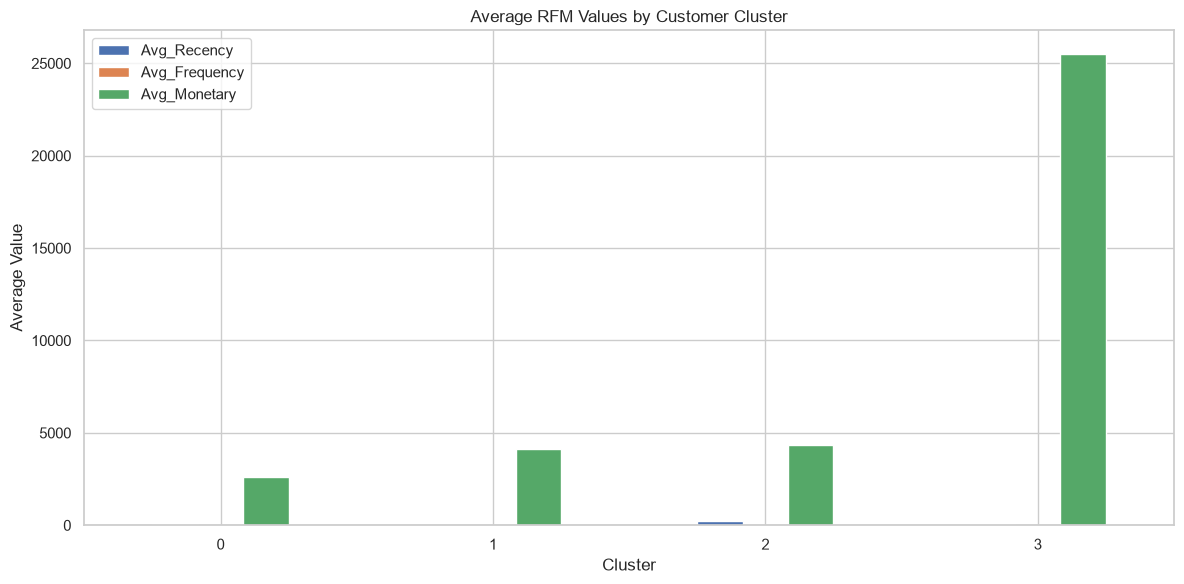

In [43]:
profile_for_plot = cluster_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
]

profile_for_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average RFM Values by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

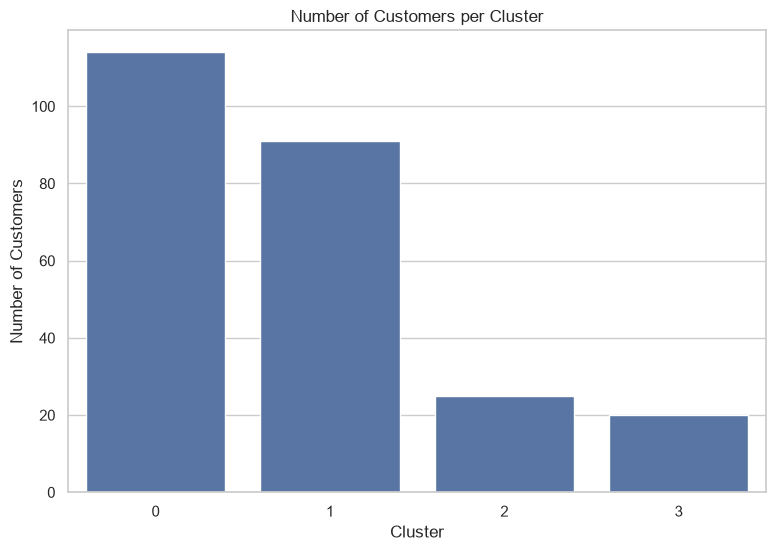

In [44]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(9, 6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

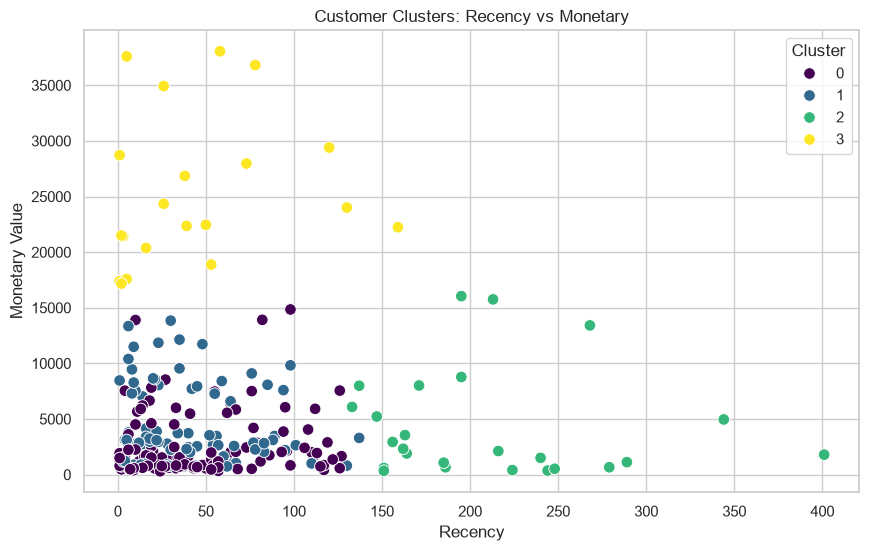

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Clusters: Recency vs Monetary")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.legend(title="Cluster")

plt.show()

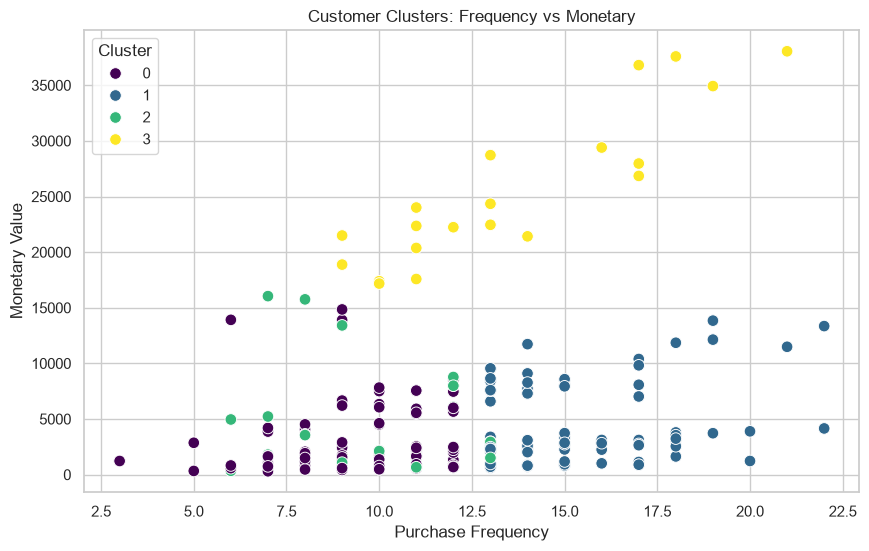

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Clusters: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.legend(title="Cluster")

plt.show()

In [47]:
cluster_profile["Segment"] = ""

for cluster in cluster_profile.index:

    recency = cluster_profile.loc[cluster, "Avg_Recency"]
    frequency = cluster_profile.loc[cluster, "Avg_Frequency"]
    monetary = cluster_profile.loc[cluster, "Avg_Monetary"]

    if (
        recency < rfm["Recency"].median()
        and frequency > rfm["Frequency"].median()
        and monetary > rfm["Monetary"].median()
    ):
        segment = "VIP / Loyal Customers"

    elif (
        recency < rfm["Recency"].median()
        and frequency >= rfm["Frequency"].median()
    ):
        segment = "Regular Customers"

    elif (
        recency > rfm["Recency"].median()
        and monetary > rfm["Monetary"].median()
    ):
        segment = "At-Risk High Value"

    else:
        segment = "Low Engagement Customers"

    cluster_profile.loc[cluster, "Segment"] = segment

display(cluster_profile.round(2))

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment
Cluster,,,,,
0,114,47.11,9.65,2603.48,At-Risk High Value
1,91,37.90,15.34,4138.96,VIP / Loyal Customers
2,25,210.48,9.28,4327.32,At-Risk High Value
3,20,44.25,13.60,25502.32,At-Risk High Value


In [48]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
)

display(cluster_profile.round(2))

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,114,47.11,9.65,2603.48
1,91,37.90,15.34,4138.96
2,25,210.48,9.28,4327.32
3,20,44.25,13.60,25502.32


In [49]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(scaled_features)

display(rfm.head())

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
CUST0001,6,18,3792.95,1
CUST0002,53,9,18880.59,3
CUST0003,55,12,7466.06,0
CUST0004,82,11,2163.30,0
CUST0005,66,17,1137.87,1


In [50]:
optimal_k = 4

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

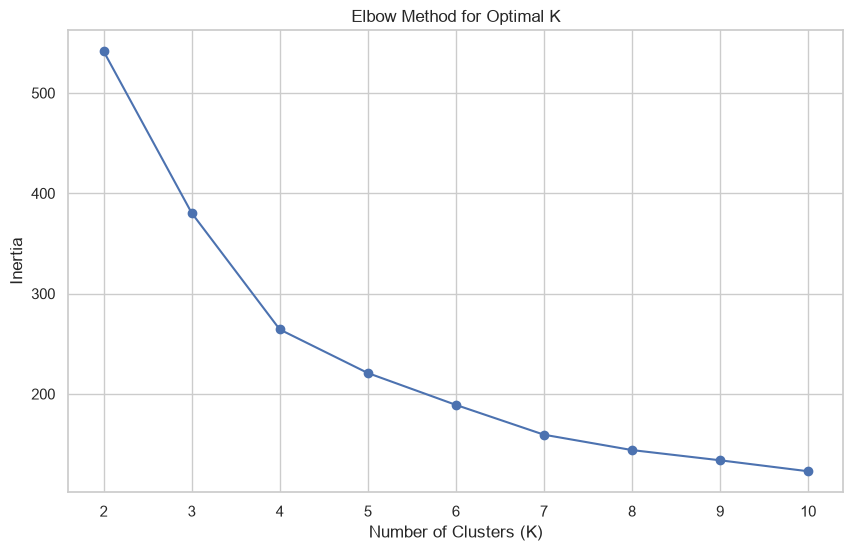

In [51]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K_range)

plt.show()



In [52]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns,
    index=features.index
)

display(scaled_df.head())

,Recency,Frequency,Monetary
CustomerID,,,
CUST0001,-0.837446,1.700597,-0.193503
CUST0002,-0.106772,-0.850299,1.931731
CUST0003,-0.075679,0.000000,0.323889
CUST0004,0.344070,-0.283433,-0.423054
CUST0005,0.095330,1.417164,-0.567495


In [53]:
features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

print("Features selected for clustering:")
print(features.columns.tolist())

Features selected for clustering:
['Recency', 'Frequency', 'Monetary']


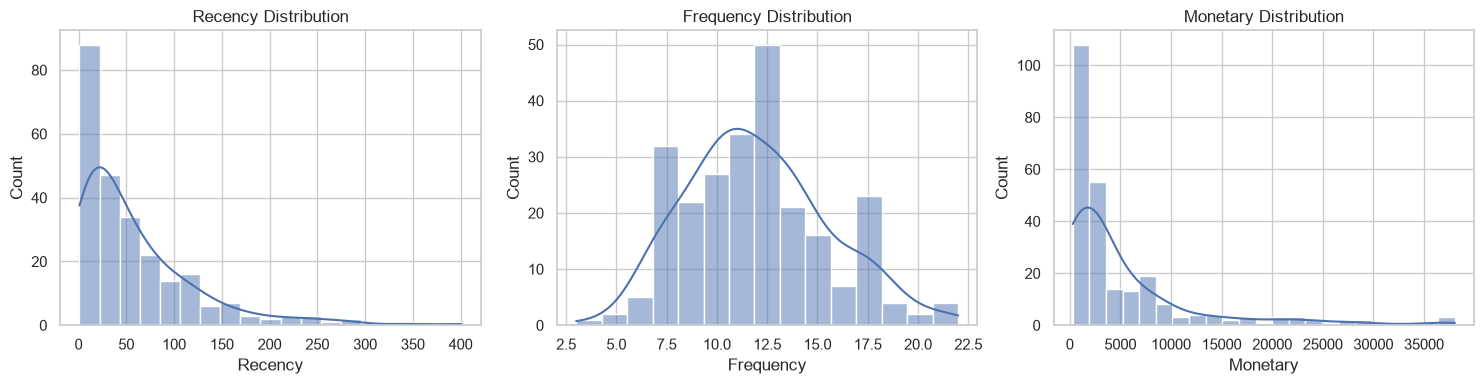

In [54]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(rfm["Recency"], kde=True)
plt.title("Recency Distribution")

plt.subplot(1, 3, 2)
sns.histplot(rfm["Frequency"], kde=True)
plt.title("Frequency Distribution")

plt.subplot(1, 3, 3)
sns.histplot(rfm["Monetary"], kde=True)
plt.title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [55]:
print("RFM Descriptive Statistics:")

display(
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ].describe()
)

RFM Descriptive Statistics:


,Recency,Frequency,Monetary
count,250.000000,250.00000,250.000000
mean,59.868000,12.00000,5166.682520
std,64.453172,3.53525,7113.526817
min,1.000000,3.00000,301.800000
25%,15.000000,10.00000,897.585000
50%,39.000000,12.00000,2280.960000
75%,82.000000,14.00000,6302.397500
max,401.000000,22.00000,38055.600000


In [56]:
# Set the analysis date as one day after the last transaction
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (analysis_date - x.max()).days
    ),

    Frequency=(
        "InvoiceNo",
        "nunique"
    ),

    Monetary=(
        "TotalPurchaseValue",
        "sum"
    )
)

display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
CUST0001,6,18,3792.95
CUST0002,53,9,18880.59
CUST0003,55,12,7466.06
CUST0004,82,11,2163.30
CUST0005,66,17,1137.87


In [57]:
customer_summary = df.groupby("CustomerID").agg(
    Total_Spending=("TotalPurchaseValue", "sum"),
    Purchase_Frequency=("InvoiceNo", "nunique"),
    Average_Purchase=("TotalPurchaseValue", "mean")
)

display(customer_summary.head())

average_purchase_value = df["TotalPurchaseValue"].mean()

print(
    f"Average Purchase Value: £{average_purchase_value:.2f}"
)
customer_summary["Customer_Lifetime_Value"] = (
    customer_summary["Total_Spending"]
)

print("Customer Lifetime Value calculated!")
display(customer_summary.head())

,Total_Spending,Purchase_Frequency,Average_Purchase
CustomerID,,,
CUST0001,3792.95,18,210.719444
CUST0002,18880.59,9,2097.843333
CUST0003,7466.06,12,622.171667
CUST0004,2163.30,11,196.663636
CUST0005,1137.87,17,66.933529


Average Purchase Value: £430.56
Customer Lifetime Value calculated!


,Total_Spending,Purchase_Frequency,Average_Purchase,Customer_Lifetime_Value
CustomerID,,,,
CUST0001,3792.95,18,210.719444,3792.95
CUST0002,18880.59,9,2097.843333,18880.59
CUST0003,7466.06,12,622.171667,7466.06
CUST0004,2163.30,11,196.663636,2163.30
CUST0005,1137.87,17,66.933529,1137.87


In [58]:
average_purchase_value = df["TotalPurchaseValue"].mean()

print(
    f"Average Purchase Value: £{average_purchase_value:.2f}"
)

Average Purchase Value: £430.56


In [59]:
df["TotalPurchaseValue"] = df["Quantity"] * df["UnitPrice"]

display(df.head())

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalPurchaseValue,ProductCategory,Country
0,INV000253,CUST0105,2023-01-01 11:34:00,5,299.18,1495.90,Clothing,Spain
1,INV002273,CUST0134,2023-01-01 12:45:00,4,88.81,355.24,Electronics,Netherlands
2,INV001428,CUST0154,2023-01-01 18:06:00,4,78.15,312.60,Beauty,United Kingdom
3,INV002088,CUST0041,2023-01-01 22:24:00,1,23.01,23.01,Beauty,United Kingdom
4,INV001505,CUST0117,2023-01-02 08:44:00,4,110.05,440.20,Clothing,Spain


In [60]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

2023-01-01 11:34:00
2024-12-31 16:11:00


In [61]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
if "InvoiceNo" in df.columns:
    df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (3000, 8)


In [62]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(3000, 8)

Column Names:
['InvoiceNo', 'CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice', 'TotalPurchaseValue', 'ProductCategory', 'Country']

Data Types:
InvoiceNo                        str
CustomerID                       str
InvoiceDate           datetime64[us]
Quantity                       int64
UnitPrice                    float64
TotalPurchaseValue           float64
ProductCategory                  str
Country                          str
dtype: object

Missing Values:


InvoiceNo             0
CustomerID            0
InvoiceDate           0
Quantity              0
UnitPrice             0
TotalPurchaseValue    0
ProductCategory       0
Country               0
dtype: int64


Duplicate Rows:
0


In [63]:
df = pd.read_csv("customer_segmentation_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (3000, 8)


,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalPurchaseValue,ProductCategory,Country
0,INV000253,CUST0105,2023-01-01 11:34:00,5,299.18,1495.90,Clothing,Spain
1,INV002273,CUST0134,2023-01-01 12:45:00,4,88.81,355.24,Electronics,Netherlands
2,INV001428,CUST0154,2023-01-01 18:06:00,4,78.15,312.60,Beauty,United Kingdom
3,INV002088,CUST0041,2023-01-01 22:24:00,1,23.01,23.01,Beauty,United Kingdom
4,INV001505,CUST0117,2023-01-02 08:44:00,4,110.05,440.20,Clothing,Spain


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!
